# Pose Training Pipeline Visualization

This notebook visualizes one random training sample through the same pose-classification pipeline used in training:
1. normalized keypoint sample
2. keypoint visibility and coordinate diagnostics
3. inference using exported best model
4. class-probability visualization

## Setup

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "training":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.pose_dataset import tennis_pose_dataset
from models.pose_classification import PoseClassificationModel

ROOT_DIR = PROJECT_ROOT / "datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation"
ANNOTATION_FILES = [
    "annotations/backhand.json",
    "annotations/forehand.json",
    "annotations/ready_position.json",
    "annotations/serve.json",
]
IMAGES_DIR = ROOT_DIR / "images"

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

def infer_pose_labels_from_folders(images_dir: Path):
    if not images_dir.exists():
        return []
    return sorted([p.name for p in images_dir.iterdir() if p.is_dir()])

folder_label_names = infer_pose_labels_from_folders(IMAGES_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {ROOT_DIR}")
print("Folder-inferred labels (alphabetical):", folder_label_names)

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Dataset root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation
Folder-inferred labels (alphabetical): ['backhand', 'forehand', 'ready_position', 'serve']


/Users/hanyiliu/Documents/GitHub/tennis-pose-detection/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Random Sample Keypoints

Random sample from the pose dataset visualized in normalized coordinate space.

Dataset label order (used for label indices): ['Backhand', 'Forehand', 'Ready_Position', 'Serve']


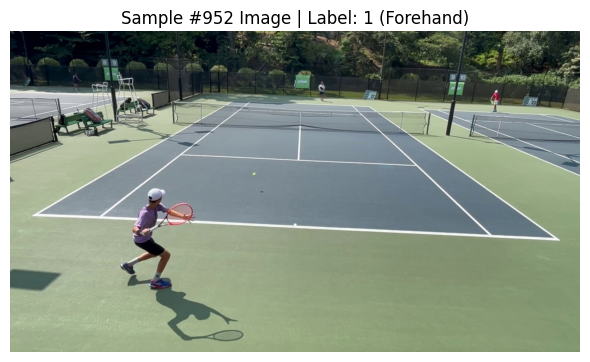

Sample image path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation/images/forehand/F_453.jpeg


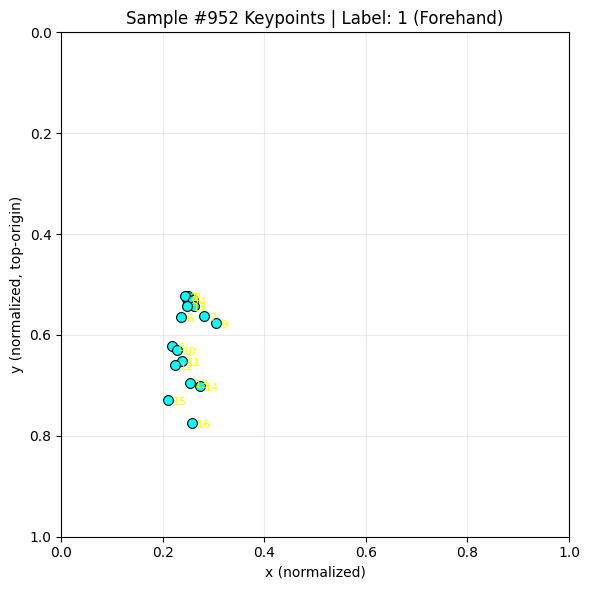

Sample keypoints shape: (18, 3)
Visible keypoints: 18 / 18
x range: (0.21015624701976776, 0.30390626192092896)
y range: (0.5222222208976746, 0.7749999761581421)


In [2]:
import json

pose_dataset = tennis_pose_dataset(
    root_dir=str(ROOT_DIR),
    annotation_files=ANNOTATION_FILES,
)
dataset_label_names = list(getattr(pose_dataset, "label_names", []))

if dataset_label_names:
    print("Dataset label order (used for label indices):", dataset_label_names)
if folder_label_names and dataset_label_names and [n.lower() for n in folder_label_names] != [n.lower() for n in dataset_label_names]:
    print("Warning: folder label order differs from dataset label order.")

pose_sample_image_paths = []
for rel_path in ANNOTATION_FILES:
    full_path = ROOT_DIR / rel_path
    with open(full_path, "r") as f:
        data = json.load(f)

    id_to_img = {img["id"]: img for img in data.get("images", [])}
    for ann in data.get("annotations", []):
        keypoints = ann.get("keypoints", None)
        if not isinstance(keypoints, list) or len(keypoints) != 54:
            continue

        cat_id = ann.get("category_id", None)
        if cat_id not in pose_dataset.label_map:
            continue

        img_info = id_to_img.get(ann["image_id"], {})
        rel_img = img_info.get("path", img_info.get("file_name", "")).replace("../", "")
        pose_sample_image_paths.append(ROOT_DIR / rel_img)

sample_idx = random.randrange(len(pose_dataset))
sample_keypoints_t, sample_label_t = pose_dataset[sample_idx]
sample_keypoints = sample_keypoints_t.numpy()  # (18, 3)
sample_label_idx = int(sample_label_t.item())
sample_image_path = pose_sample_image_paths[sample_idx] if sample_idx < len(pose_sample_image_paths) else None

name_source = dataset_label_names if dataset_label_names else folder_label_names
sample_label_name = (
    name_source[sample_label_idx]
    if sample_label_idx < len(name_source)
    else f"class_{sample_label_idx}"
)

if sample_image_path is not None and sample_image_path.exists():
    sample_img = plt.imread(sample_image_path)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(sample_img)
    ax.set_title(f"Sample #{sample_idx} Image | Label: {sample_label_idx} ({sample_label_name})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Sample image path: {sample_image_path}")
else:
    print("Sample image not found for the selected index.")

visible_mask = sample_keypoints[:, 2] > 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    sample_keypoints[visible_mask, 0],
    sample_keypoints[visible_mask, 1],
    c="cyan",
    s=50,
    edgecolors="black",
    linewidths=0.8,
)
for i in np.where(visible_mask)[0]:
    xk, yk = sample_keypoints[i, 0], sample_keypoints[i, 1]
    ax.text(xk + 0.01, yk + 0.01, str(i), color="yellow", fontsize=8)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(1.0, 0.0)
ax.set_xlabel("x (normalized)")
ax.set_ylabel("y (normalized, top-origin)")
ax.set_title(f"Sample #{sample_idx} Keypoints | Label: {sample_label_idx} ({sample_label_name})")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Sample keypoints shape:", sample_keypoints.shape)
print("Visible keypoints:", int(visible_mask.sum()), "/", sample_keypoints.shape[0])
print("x range:", (float(sample_keypoints[:, 0].min()), float(sample_keypoints[:, 0].max())))
print("y range:", (float(sample_keypoints[:, 1].min()), float(sample_keypoints[:, 1].max())))

## 2) Normalized Keypoint Matrix Diagnostics

Inspect the `(18,3)` feature matrix used by the Stage-3 classifier.

Keypoint matrix (rows=joint index, cols=[x_norm, y_norm, visibility]):
[[0.246875   0.5277778  1.        ]
 [0.2453125  0.5222222  1.        ]
 [0.25       0.5236111  1.        ]
 [0.24296875 0.5222222  1.        ]
 [0.26015624 0.53055555 2.        ]
 [0.2609375  0.5416667  1.        ]
 [0.2359375  0.5638889  2.        ]
 [0.28046876 0.5625     2.        ]
 [0.21796875 0.62222224 2.        ]
 [0.30390626 0.5763889  2.        ]
 [0.22890624 0.62916666 2.        ]
 [0.2375     0.6513889  1.        ]
 [0.2234375  0.6597222  2.        ]
 [0.253125   0.6958333  2.        ]
 [0.2734375  0.7013889  2.        ]
 [0.21015625 0.7291667  2.        ]
 [0.25703126 0.775      2.        ]
 [0.2484375  0.5416667  2.        ]]


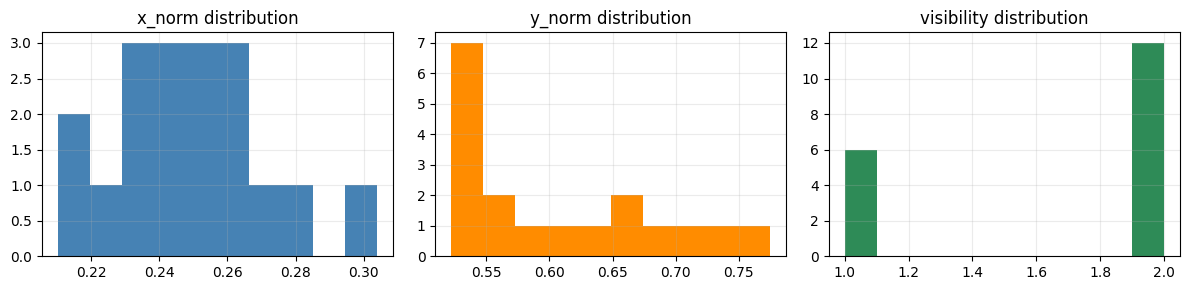

In [3]:
print("Keypoint matrix (rows=joint index, cols=[x_norm, y_norm, visibility]):")
print(sample_keypoints)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(sample_keypoints[:, 0], bins=10, color="steelblue")
axes[0].set_title("x_norm distribution")
axes[1].hist(sample_keypoints[:, 1], bins=10, color="darkorange")
axes[1].set_title("y_norm distribution")
axes[2].hist(sample_keypoints[:, 2], bins=10, color="seagreen")
axes[2].set_title("visibility distribution")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3) Inference with Exported Best Model

Loads pose model from `exports/` first, with checkpoint fallback.

In [4]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

export_ckpt = PROJECT_ROOT / "exports" / "pose_best.pt"
fallback_ckpt = PROJECT_ROOT / "checkpoints" / "pose_best.pt"
if export_ckpt.exists():
    checkpoint_path = export_ckpt
elif fallback_ckpt.exists():
    checkpoint_path = fallback_ckpt
else:
    raise FileNotFoundError(f"No pose checkpoint found. Checked: {export_ckpt} and {fallback_ckpt}")

device = get_device()
checkpoint = torch.load(checkpoint_path, map_location=device)

args = checkpoint.get("args", {}) if isinstance(checkpoint, dict) else {}
hidden_dim = args.get("hidden_dim", 256)
dropout = args.get("dropout", 0.25)
visibility_threshold = args.get("visibility_threshold", 0.0)

pose_model = PoseClassificationModel(
    num_keypoints=18,
    num_classes=4,
    hidden_dim=hidden_dim,
    dropout=dropout,
    visibility_threshold=visibility_threshold,
).to(device)

if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    state_dict = checkpoint["model_state"]
else:
    state_dict = checkpoint
pose_model.load_state_dict(state_dict)
pose_model.eval()

model_input = sample_keypoints_t.unsqueeze(0).to(device)

with torch.no_grad():
    probs = pose_model(model_input).squeeze(0).detach().cpu().numpy()

checkpoint_label_names = checkpoint.get("label_names", None) if isinstance(checkpoint, dict) else None
if isinstance(checkpoint_label_names, list) and len(checkpoint_label_names) == len(probs):
    label_names_for_display = checkpoint_label_names
elif isinstance(dataset_label_names, list) and len(dataset_label_names) == len(probs):
    label_names_for_display = dataset_label_names
elif isinstance(folder_label_names, list) and len(folder_label_names) == len(probs):
    label_names_for_display = folder_label_names
else:
    label_names_for_display = [f"class_{i}" for i in range(len(probs))]

pred_idx = int(np.argmax(probs))
pred_name = label_names_for_display[pred_idx] if pred_idx < len(label_names_for_display) else f"class_{pred_idx}"
true_name = (
    label_names_for_display[sample_label_idx]
    if sample_label_idx < len(label_names_for_display)
    else f"class_{sample_label_idx}"
)

print(f"Loaded model from: {checkpoint_path}")
print("Label names used for display:", label_names_for_display)
print(f"True label: {sample_label_idx} ({true_name})")
print(f"Pred label: {pred_idx} ({pred_name})")
print("Probabilities:", probs)

Loaded model from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/pose_best_predicted.pt
Label names used for display: ['Backhand', 'Forehand', 'Ready_Position', 'Serve']
True label: 1 (Forehand)
Pred label: 3 (Serve)
Probabilities: [0.08891994 0.0490475  0.02279777 0.8392348 ]


## 4) Class Probability Diagnostics

Visualize predicted probability distribution for the selected sample.

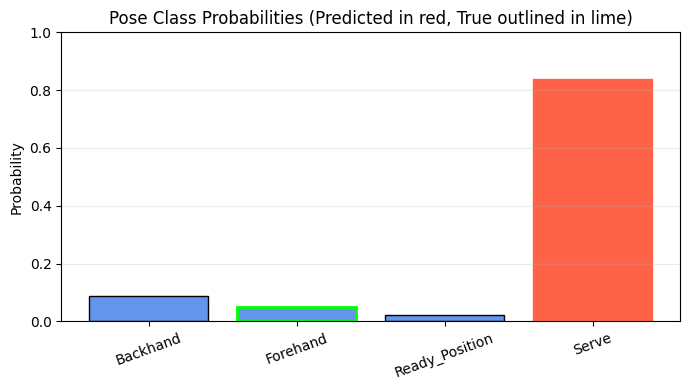

Top-2 classes:
1. 3 (Serve): 0.8392
2. 0 (Backhand): 0.0889


In [5]:
if "label_names_for_display" in globals() and len(label_names_for_display) == len(probs):
    class_labels = label_names_for_display
else:
    class_labels = [f"class_{i}" for i in range(len(probs))]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_labels, probs, color="cornflowerblue", edgecolor="black")
bars[pred_idx].set_color("tomato")
if sample_label_idx < len(bars):
    bars[sample_label_idx].set_edgecolor("lime")
    bars[sample_label_idx].set_linewidth(2.0)

ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Probability")
ax.set_title("Pose Class Probabilities (Predicted in red, True outlined in lime)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

top2_idx = np.argsort(probs)[-2:][::-1]
print("Top-2 classes:")
for rank, idx in enumerate(top2_idx, start=1):
    name = class_labels[idx]
    print(f"{rank}. {idx} ({name}): {probs[idx]:.4f}")

## Evaluation

Measure accuracy against training and cv dataset.

In [6]:
# Evaluate accuracy on train split vs CV split (CV = val + test)
n_samples = len(pose_dataset)
split_seed = int(args.get("seed", 42))
train_ratio = float(args.get("train_split", 0.7))
val_ratio = float(args.get("val_split", 0.15))

rng = np.random.default_rng(split_seed)
all_indices = rng.permutation(n_samples)

def evaluate_subset(indices, batch_size=256):
    subset = torch.utils.data.Subset(pose_dataset, indices.tolist() if hasattr(indices, "tolist") else list(indices))
    loader = torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=False)

    correct, total = 0, 0
    class_correct = np.zeros(len(label_names_for_display), dtype=np.int64)
    class_total = np.zeros(len(label_names_for_display), dtype=np.int64)

    pose_model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = pose_model(x)
            pred = out.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.numel()

            y_cpu = y.detach().cpu().numpy()
            p_cpu = pred.detach().cpu().numpy()
            for t, p in zip(y_cpu, p_cpu):
                class_total[t] += 1
                if p == t:
                    class_correct[t] += 1

    acc = correct / total if total > 0 else 0.0
    class_acc = np.divide(
        class_correct,
        np.maximum(class_total, 1),
        dtype=np.float64,
    )
    return acc, class_correct, class_total, class_acc

acc, c_ok, c_n, c_acc = evaluate_subset(all_indices)

print(f"Total samples: {n_samples}")
print(f"Accuracy: {acc:.4f}")

print("\nPer-class accuracy:")
for i, name in enumerate(label_names_for_display):
    print(f"- {i} ({name}): {c_acc[i]:.4f} ({c_ok[i]}/{c_n[i]})")

Total samples: 2000
Accuracy: 0.4530

Per-class accuracy:
- 0 (Backhand): 0.3500 (175/500)
- 1 (Forehand): 0.0000 (0/500)
- 2 (Ready_Position): 0.5640 (282/500)
- 3 (Serve): 0.8980 (449/500)
